# Lab 3: Contextual Bandit-Based News Article Recommendation

**`Course`:** Reinforcement Learning Fundamentals  
**`Student Name`:** Akshat  
**`Roll Number`:** U20230093  
**`GitHub Branch`:** akshat_U20230093  

# Imports and Setup

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

from rlcmab_sampler import sampler

# Load Datasets

In [7]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print("=== News Articles ===")
print(f"Shape: {news_df.shape}")
print(f"Columns: {news_df.columns.tolist()}")
print(news_df.head())

print("\n=== Train Users ===")
print(f"Shape: {train_users.shape}")
print(f"Columns: {train_users.columns.tolist()}")
print(train_users.head())

print("\n=== Test Users ===")
print(f"Shape: {test_users.shape}")
print(test_users.head())

=== News Articles ===
Shape: (209527, 6)
Columns: ['link', 'headline', 'category', 'short_description', 'authors', 'date']
                                                link  \
0  https://www.huffpost.com/entry/covid-boosters-...   
1  https://www.huffpost.com/entry/american-airlin...   
2  https://www.huffpost.com/entry/funniest-tweets...   
3  https://www.huffpost.com/entry/funniest-parent...   
4  https://www.huffpost.com/entry/amy-cooper-lose...   

                                            headline   category  \
0  Over 4 Million Americans Roll Up Sleeves For O...  U.S. NEWS   
1  American Airlines Flyer Charged, Banned For Li...  U.S. NEWS   
2  23 Of The Funniest Tweets About Cats And Dogs ...     COMEDY   
3  The Funniest Tweets From Parents This Week (Se...  PARENTING   
4  Woman Who Called Cops On Black Bird-Watcher Lo...  U.S. NEWS   

                                   short_description               authors  \
0  Health experts said it is too early to predict...  Carla

## Data Preprocessing

In this section:
- Handle missing values
- Encode categorical features
- Prepare data for user classification

In [8]:
# --- Data Preprocessing ---

# 1. Check for missing values
print("Missing values in train_users:")
print(train_users.isnull().sum()[train_users.isnull().sum() > 0])
print(f"\nMissing values in test_users:")
print(test_users.isnull().sum()[test_users.isnull().sum() > 0])

# 2. Columns to drop (non-predictive or high-cardinality)
drop_cols = ['user_id', 'label', 'browser_version']

# 3. Build feature matrix
def preprocess(df, fit=False):
    X = df.copy()
    
    # Fill missing age with median
    if fit:
        preprocess.age_median = X['age'].median()
    X['age'] = X['age'].fillna(preprocess.age_median)
    
    # Encode region_code via frequency encoding (handles unseen values)
    if fit:
        preprocess.region_freq = X['region_code'].value_counts(normalize=True).to_dict()
    X['region_code'] = X['region_code'].map(preprocess.region_freq).fillna(0.0)
    
    # Encode subscriber as int
    X['subscriber'] = X['subscriber'].astype(int)
    
    # Drop non-feature columns
    cols_to_drop = [c for c in drop_cols if c in X.columns]
    X = X.drop(columns=cols_to_drop)
    
    feature_names = X.columns.tolist()
    
    # Scale features
    if fit:
        preprocess.scaler = StandardScaler()
        X_scaled = preprocess.scaler.fit_transform(X)
    else:
        X_scaled = preprocess.scaler.transform(X)
    
    return X_scaled, feature_names

# 4. Apply preprocessing on full train set (fit scaler/encoders here)
X_all, feature_names = preprocess(train_users, fit=True)
y_all = LabelEncoder().fit_transform(train_users['label'])

# 5. 80/20 train-validation split (as per assignment spec)
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

# 6. Preprocess test set (no labels available)
X_test, _ = preprocess(test_users, fit=False)

# 7. Encode target labels
le = LabelEncoder()
le.fit(train_users['label'])

print(f"\nLabel mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}")
print(f"Features ({len(feature_names)}): {feature_names}")
print(f"Full training set:  {X_all.shape[0]} samples")
print(f"  Train split (80%): {X_train.shape[0]} samples")
print(f"  Val split (20%):   {X_val.shape[0]} samples")
print(f"Test set:            {X_test.shape[0]} samples")

Missing values in train_users:
age    698
dtype: int64

Missing values in test_users:
age    679
dtype: int64

Label mapping: {'user_1': np.int64(0), 'user_2': np.int64(1), 'user_3': np.int64(2)}
Features (30): ['age', 'income', 'clicks', 'purchase_amount', 'session_duration', 'content_variety', 'engagement_score', 'num_transactions', 'avg_monthly_spend', 'avg_cart_value', 'browsing_depth', 'revisit_rate', 'scroll_activity', 'time_on_site', 'interaction_count', 'preferred_price_range', 'discount_usage_rate', 'wishlist_size', 'product_views', 'repeat_purchase_gap (days)', 'churn_risk_score', 'loyalty_index', 'screen_brightness', 'battery_percentage', 'cart_abandonment_count', 'background_app_count', 'session_inactivity_duration', 'network_jitter', 'region_code', 'subscriber']
Full training set:  2000 samples
  Train split (80%): 1600 samples
  Val split (20%):   400 samples
Test set:            2000 samples


## User Classification

Train a classifier to predict the user category (`User1`, `User2`, `User3`),
which serves as the **context** for the contextual bandit.


In [9]:
# --- User Classification ---
# Train a Gradient Boosting classifier to predict user category (context)

clf = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    random_state=42
)

# Train on 80% training split
clf.fit(X_train, y_train)

# --- Evaluate on 20% validation split ---
y_val_pred = clf.predict(X_val)
val_acc = accuracy_score(y_val, y_val_pred)

print(f"Validation Accuracy (20% split): {val_acc:.4f}")
print("\n--- Classification Report (Validation Set) ---")
print(classification_report(y_val, y_val_pred, target_names=le.classes_))

# Training accuracy
y_train_pred = clf.predict(X_train)
train_acc = accuracy_score(y_train, y_train_pred)
print(f"Training Accuracy (80% split): {train_acc:.4f}")

# --- Retrain on full training set for best context detection on test_users ---
clf.fit(X_all, le.transform(train_users['label']))

# Predict on test_users (context detection for bandit)
y_test_pred = clf.predict(X_test)
test_users['predicted_label'] = le.inverse_transform(y_test_pred)

print(f"\nTest set predictions distribution:")
print(test_users['predicted_label'].value_counts())

# Feature importance (top 10)
importances = clf.feature_importances_
sorted_idx = np.argsort(importances)[::-1]
print("\nTop 10 Feature Importances:")
for i in sorted_idx[:10]:
    print(f"  {feature_names[i]:30s}: {importances[i]:.4f}")

Validation Accuracy (20% split): 0.9150

--- Classification Report (Validation Set) ---
              precision    recall  f1-score   support

      user_1       0.89      0.87      0.88       142
      user_2       0.98      0.89      0.94       142
      user_3       0.88      0.99      0.93       116

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.91       400

Training Accuracy (80% split): 1.0000

Test set predictions distribution:
predicted_label
user_2    696
user_1    663
user_3    641
Name: count, dtype: int64

Top 10 Feature Importances:
  region_code                   : 0.4373
  session_duration              : 0.3441
  scroll_activity               : 0.0171
  preferred_price_range         : 0.0158
  churn_risk_score              : 0.0123
  content_variety               : 0.0122
  income                        : 0.0113
  session_inactivity_duration   : 0.0106
  battery_percen

# `Contextual Bandit`

## Reward Sampler Initialization

The sampler is initialized using the student's roll number `i`.
Rewards are obtained using `sampler.sample(j)`.


In [10]:
# --- Reward Sampler Initialization ---
# Roll number: U20230093 -> i = 93
reward_sampler = sampler(93)

# Quick test: sample one reward from each arm
print("Sample rewards from each arm:")
for j in range(12):
    r = reward_sampler.sample(j)
    print(f"  Arm {j:2d}: reward = {r:.4f}")

Sample rewards from each arm:
  Arm  0: reward = 2.8738
  Arm  1: reward = -3.3072
  Arm  2: reward = -7.0612
  Arm  3: reward = 3.5113
  Arm  4: reward = -1.8928
  Arm  5: reward = -1.5279
  Arm  6: reward = -8.8720
  Arm  7: reward = 10.0335
  Arm  8: reward = 0.0470
  Arm  9: reward = 2.3016
  Arm 10: reward = -8.9721
  Arm 11: reward = 2.8535


## Arm Mapping

| Arm Index (j) | News Category | User Context |
|--------------|---------------|--------------|
| 0–3          | Entertainment, Education, Tech, Crime | User1 |
| 4–7          | Entertainment, Education, Tech, Crime | User2 |
| 8–11         | Entertainment, Education, Tech, Crime | User3 |

In [11]:
# --- Arm Mapping ---
NEWS_CATEGORIES = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
USER_CONTEXTS   = ['user_1', 'user_2', 'user_3']

N_CATEGORIES = len(NEWS_CATEGORIES)   # 4
N_CONTEXTS   = len(USER_CONTEXTS)     # 3
N_ARMS       = N_CONTEXTS * N_CATEGORIES  # 12

def get_arm_index(context_idx, category_idx):
    """Map (context, category) -> arm index j."""
    return context_idx * N_CATEGORIES + category_idx

def get_context_category(arm_idx):
    """Map arm index j -> (context_idx, category_idx)."""
    return divmod(arm_idx, N_CATEGORIES)

# Verify mapping
print("Arm Mapping:")
for ctx_i, ctx in enumerate(USER_CONTEXTS):
    for cat_i, cat in enumerate(NEWS_CATEGORIES):
        j = get_arm_index(ctx_i, cat_i)
        print(f"  Arm {j:2d} -> {ctx} x {cat}")

Arm Mapping:
  Arm  0 -> user_1 x ENTERTAINMENT
  Arm  1 -> user_1 x EDUCATION
  Arm  2 -> user_1 x TECH
  Arm  3 -> user_1 x CRIME
  Arm  4 -> user_2 x ENTERTAINMENT
  Arm  5 -> user_2 x EDUCATION
  Arm  6 -> user_2 x TECH
  Arm  7 -> user_2 x CRIME
  Arm  8 -> user_3 x ENTERTAINMENT
  Arm  9 -> user_3 x EDUCATION
  Arm 10 -> user_3 x TECH
  Arm 11 -> user_3 x CRIME


## Epsilon-Greedy Strategy

This section implements the epsilon-greedy contextual bandit algorithm.


In [12]:
# --- Epsilon-Greedy Contextual Bandit ---

def epsilon_greedy(sampler_obj, T, epsilon, context_arms):
    """
    Epsilon-Greedy algorithm for a single context.
    
    Parameters:
        sampler_obj: reward sampler
        T: number of time steps
        epsilon: exploration probability
        context_arms: list of arm indices for this context (length = N_CATEGORIES)
    
    Returns:
        rewards: array of rewards at each step
        arm_counts: number of times each arm was pulled
        arm_means: estimated mean reward for each arm
        best_arm: index of the best arm found
    """
    n_arms = len(context_arms)
    arm_counts = np.zeros(n_arms)
    arm_sum    = np.zeros(n_arms)
    arm_means  = np.zeros(n_arms)
    rewards    = np.zeros(T)
    
    for t in range(T):
        if np.random.random() < epsilon or np.min(arm_counts) == 0:
            # Explore: pick a random arm (or one that hasn't been tried)
            if np.min(arm_counts) == 0:
                a = np.argmin(arm_counts)
            else:
                a = np.random.randint(n_arms)
        else:
            # Exploit: pick arm with highest estimated mean
            a = np.argmax(arm_means)
        
        # Pull arm
        j = context_arms[a]
        r = sampler_obj.sample(j)
        
        # Update
        arm_counts[a] += 1
        arm_sum[a] += r
        arm_means[a] = arm_sum[a] / arm_counts[a]
        rewards[t] = r
    
    best_arm = np.argmax(arm_means)
    return rewards, arm_counts, arm_means, best_arm

# --- Run Epsilon-Greedy for multiple epsilon values across all contexts ---
T = 10000
EPSILONS = [0.01, 0.1, 0.3]

eg_results = {}  # {epsilon: {context_idx: {rewards, counts, means, best_arm}}}

for eps in EPSILONS:
    eg_results[eps] = {}
    for ctx_i, ctx_name in enumerate(USER_CONTEXTS):
        arms = [get_arm_index(ctx_i, cat_i) for cat_i in range(N_CATEGORIES)]
        rewards, counts, means, best = epsilon_greedy(reward_sampler, T, eps, arms)
        eg_results[eps][ctx_i] = {
            'rewards': rewards,
            'counts': counts,
            'means': means,
            'best_arm': best,
            'context_name': ctx_name
        }
        print(f"ε={eps}, {ctx_name}: best_category={NEWS_CATEGORIES[best]}, "
              f"mean_reward={np.mean(rewards):.3f}, "
              f"arm_means={np.round(means, 3)}")
    print()

print("Epsilon-Greedy complete.")

ε=0.01, user_1: best_category=ENTERTAINMENT, mean_reward=3.010, arm_means=[ 3.046 -2.559 -7.693  3.034]
ε=0.01, user_2: best_category=CRIME, mean_reward=9.188, arm_means=[-2.727  0.662 -8.434  9.299]
ε=0.01, user_3: best_category=CRIME, mean_reward=3.728, arm_means=[-0.782 -1.199 -7.521  3.784]

ε=0.1, user_1: best_category=CRIME, mean_reward=2.752, arm_means=[ 3.067 -2.589 -7.746  3.181]
ε=0.1, user_2: best_category=CRIME, mean_reward=8.316, arm_means=[-2.709  0.226 -8.589  9.32 ]
ε=0.1, user_3: best_category=CRIME, mean_reward=3.297, arm_means=[-0.663 -1.034 -7.148  3.785]

ε=0.3, user_1: best_category=CRIME, mean_reward=1.900, arm_means=[ 3.067 -2.511 -7.753  3.156]
ε=0.3, user_2: best_category=CRIME, mean_reward=6.387, arm_means=[-2.911  0.342 -8.51   9.321]
ε=0.3, user_3: best_category=CRIME, mean_reward=2.269, arm_means=[-0.756 -1.037 -7.134  3.776]

Epsilon-Greedy complete.


## Upper Confidence Bound (UCB)

This section implements the UCB strategy for contextual bandits.

In [13]:
# --- Upper Confidence Bound (UCB) ---

def ucb(sampler_obj, T, c, context_arms):
    """
    UCB algorithm for a single context.
    
    Parameters:
        sampler_obj: reward sampler
        T: number of time steps
        c: exploration parameter (controls confidence interval width)
        context_arms: list of arm indices for this context
    
    Returns:
        rewards, arm_counts, arm_means, best_arm
    """
    n_arms = len(context_arms)
    arm_counts = np.zeros(n_arms)
    arm_sum    = np.zeros(n_arms)
    arm_means  = np.zeros(n_arms)
    rewards    = np.zeros(T)
    
    for t in range(T):
        # First, ensure each arm is tried at least once
        if np.min(arm_counts) == 0:
            a = np.argmin(arm_counts)
        else:
            # UCB formula: mean + c * sqrt(ln(t) / N(a))
            ucb_values = arm_means + c * np.sqrt(np.log(t + 1) / arm_counts)
            a = np.argmax(ucb_values)
        
        # Pull arm
        j = context_arms[a]
        r = sampler_obj.sample(j)
        
        # Update
        arm_counts[a] += 1
        arm_sum[a] += r
        arm_means[a] = arm_sum[a] / arm_counts[a]
        rewards[t] = r
    
    best_arm = np.argmax(arm_means)
    return rewards, arm_counts, arm_means, best_arm

# --- Run UCB for multiple c values across all contexts ---
C_VALUES = [0.5, 1.0, 2.0]

ucb_results = {}  # {c: {context_idx: {...}}}

for c_val in C_VALUES:
    ucb_results[c_val] = {}
    for ctx_i, ctx_name in enumerate(USER_CONTEXTS):
        arms = [get_arm_index(ctx_i, cat_i) for cat_i in range(N_CATEGORIES)]
        rewards, counts, means, best = ucb(reward_sampler, T, c_val, arms)
        ucb_results[c_val][ctx_i] = {
            'rewards': rewards,
            'counts': counts,
            'means': means,
            'best_arm': best,
            'context_name': ctx_name
        }
        print(f"c={c_val}, {ctx_name}: best_category={NEWS_CATEGORIES[best]}, "
              f"mean_reward={np.mean(rewards):.3f}, "
              f"arm_means={np.round(means, 3)}")
    print()

print("UCB complete.")

c=0.5, user_1: best_category=CRIME, mean_reward=3.185, arm_means=[ 2.842 -1.366 -7.376  3.187]
c=0.5, user_2: best_category=CRIME, mean_reward=9.319, arm_means=[-1.81   0.338 -8.202  9.323]
c=0.5, user_3: best_category=CRIME, mean_reward=3.771, arm_means=[-3.182  0.917 -6.063  3.773]

c=1.0, user_1: best_category=CRIME, mean_reward=3.157, arm_means=[ 3.066 -1.932 -5.549  3.164]
c=1.0, user_2: best_category=CRIME, mean_reward=9.299, arm_means=[-2.418 -0.892 -9.539  9.303]
c=1.0, user_3: best_category=CRIME, mean_reward=3.760, arm_means=[ 0.059 -2.235 -5.173  3.762]

c=2.0, user_1: best_category=CRIME, mean_reward=3.177, arm_means=[ 3.086 -3.939 -6.303  3.193]
c=2.0, user_2: best_category=CRIME, mean_reward=9.300, arm_means=[ -5.326   0.42  -10.016   9.305]
c=2.0, user_3: best_category=CRIME, mean_reward=3.763, arm_means=[-0.748 -1.061 -7.045  3.767]

UCB complete.


## SoftMax Strategy

This section implements the SoftMax strategy with temperature $ \tau = 1$.


In [14]:
# --- SoftMax Strategy ---

def softmax_bandit(sampler_obj, T, tau, context_arms):
    """
    SoftMax (Boltzmann) exploration strategy for a single context.
    
    Parameters:
        sampler_obj: reward sampler
        T: number of time steps
        tau: temperature parameter (higher -> more exploration)
        context_arms: list of arm indices for this context
    
    Returns:
        rewards, arm_counts, arm_means, best_arm
    """
    n_arms = len(context_arms)
    arm_counts = np.zeros(n_arms)
    arm_sum    = np.zeros(n_arms)
    arm_means  = np.zeros(n_arms)
    rewards    = np.zeros(T)
    
    for t in range(T):
        # Ensure each arm is tried at least once
        if np.min(arm_counts) == 0:
            a = np.argmin(arm_counts)
        else:
            # SoftMax probabilities: P(a) = exp(Q(a)/tau) / sum(exp(Q/tau))
            logits = arm_means / tau
            logits -= np.max(logits)  # numerical stability
            exp_logits = np.exp(logits)
            probs = exp_logits / np.sum(exp_logits)
            a = np.random.choice(n_arms, p=probs)
        
        # Pull arm
        j = context_arms[a]
        r = sampler_obj.sample(j)
        
        # Update
        arm_counts[a] += 1
        arm_sum[a] += r
        arm_means[a] = arm_sum[a] / arm_counts[a]
        rewards[t] = r
    
    best_arm = np.argmax(arm_means)
    return rewards, arm_counts, arm_means, best_arm

# --- Run SoftMax for multiple tau values ---
TAU_VALUES = [0.1, 1.0, 5.0]

sm_results = {}  # {tau: {context_idx: {...}}}

for tau in TAU_VALUES:
    sm_results[tau] = {}
    for ctx_i, ctx_name in enumerate(USER_CONTEXTS):
        arms = [get_arm_index(ctx_i, cat_i) for cat_i in range(N_CATEGORIES)]
        rewards, counts, means, best = softmax_bandit(reward_sampler, T, tau, arms)
        sm_results[tau][ctx_i] = {
            'rewards': rewards,
            'counts': counts,
            'means': means,
            'best_arm': best,
            'context_name': ctx_name
        }
        print(f"τ={tau}, {ctx_name}: best_category={NEWS_CATEGORIES[best]}, "
              f"mean_reward={np.mean(rewards):.3f}, "
              f"arm_means={np.round(means, 3)}")
    print()

print("SoftMax complete.")

τ=0.1, user_1: best_category=CRIME, mean_reward=3.179, arm_means=[ 2.289 -3.702 -6.219  3.181]
τ=0.1, user_2: best_category=CRIME, mean_reward=9.320, arm_means=[-3.108 -0.77  -8.515  9.324]
τ=0.1, user_3: best_category=CRIME, mean_reward=3.762, arm_means=[ 1.218 -0.51  -6.774  3.764]

τ=1.0, user_1: best_category=CRIME, mean_reward=3.105, arm_means=[ 3.042 -2.563 -6.205  3.196]
τ=1.0, user_2: best_category=CRIME, mean_reward=9.321, arm_means=[ -1.203  -0.226 -10.546   9.327]
τ=1.0, user_3: best_category=CRIME, mean_reward=3.666, arm_means=[-0.593 -1.15  -7.175  3.77 ]

τ=5.0, user_1: best_category=CRIME, mean_reward=1.835, arm_means=[ 3.046 -2.41  -7.73   3.168]
τ=5.0, user_2: best_category=CRIME, mean_reward=6.894, arm_means=[-2.784  0.364 -8.513  9.303]
τ=5.0, user_3: best_category=CRIME, mean_reward=1.209, arm_means=[-0.733 -1.034 -7.182  3.789]

SoftMax complete.


## Reinforcement Learning Simulation

We simulate the bandit algorithms for $T = 10,000$ steps and record rewards.

P.S.: Change $T$ value as and if required.


In [15]:
# --- Recommendation Engine ---
# For each test user:
#   1. Use classifier to predict context (already in test_users['predicted_label'])
#   2. Use the best bandit policy (UCB with c=1.0 gave best balance) to pick category
#   3. Sample a random article from that category

# Build best policy lookup from UCB c=1.0 results (best overall performer)
best_policy = {}  # context_name -> best_category
for ctx_i, ctx_name in enumerate(USER_CONTEXTS):
    best_cat_idx = ucb_results[1.0][ctx_i]['best_arm']
    best_policy[ctx_name] = NEWS_CATEGORIES[best_cat_idx]

print("Best Policy (UCB c=1.0):")
for ctx, cat in best_policy.items():
    print(f"  {ctx} -> recommend {cat}")

# Filter news articles to only the 4 relevant categories
relevant_news = news_df[news_df['category'].isin(NEWS_CATEGORIES)].copy()
print(f"\nRelevant news articles: {len(relevant_news)}")
print(relevant_news['category'].value_counts())

# Generate recommendations for test users
recommendations = []
for idx, row in test_users.iterrows():
    context = row['predicted_label']
    rec_category = best_policy[context]
    
    # Sample a random article from the recommended category
    articles = relevant_news[relevant_news['category'] == rec_category]
    article = articles.sample(1, random_state=idx).iloc[0]
    
    recommendations.append({
        'user_id': row['user_id'],
        'predicted_context': context,
        'recommended_category': rec_category,
        'article_headline': article['headline'],
        'article_link': article['link']
    })

rec_df = pd.DataFrame(recommendations)
print(f"\n--- Sample Recommendations (first 10) ---")
print(rec_df[['user_id', 'predicted_context', 'recommended_category', 'article_headline']].head(10).to_string())

print(f"\nRecommendation distribution:")
print(rec_df['recommended_category'].value_counts())
print(f"\nTotal recommendations: {len(rec_df)}")

Best Policy (UCB c=1.0):
  user_1 -> recommend CRIME
  user_2 -> recommend CRIME
  user_3 -> recommend CRIME

Relevant news articles: 24042
category
ENTERTAINMENT    17362
CRIME             3562
TECH              2104
EDUCATION         1014
Name: count, dtype: int64

--- Sample Recommendations (first 10) ---
  user_id predicted_context recommended_category                                                                        article_headline
0   U4058            user_3                CRIME                  John Hinckley Jr., Reagan's Would-Be Assassin, Released After 35 Years
1   U1118            user_1                CRIME                   Brother Of ‘Doomsday’ Mom Lori Vallow Died Of Natural Causes: Autopsy
2   U6555            user_1                CRIME                Man Fatally Shot Ice Cream Truck Driver In Front Of Children, Police Say
3   U9170            user_1                CRIME  Taping Police Interrogations Could Have Prevented This Horrific Miscarriage of Justice
4   U

## Results and Analysis

This section presents:
- Average Reward vs Time
- Hyperparameter comparisons
- Observations and discussion


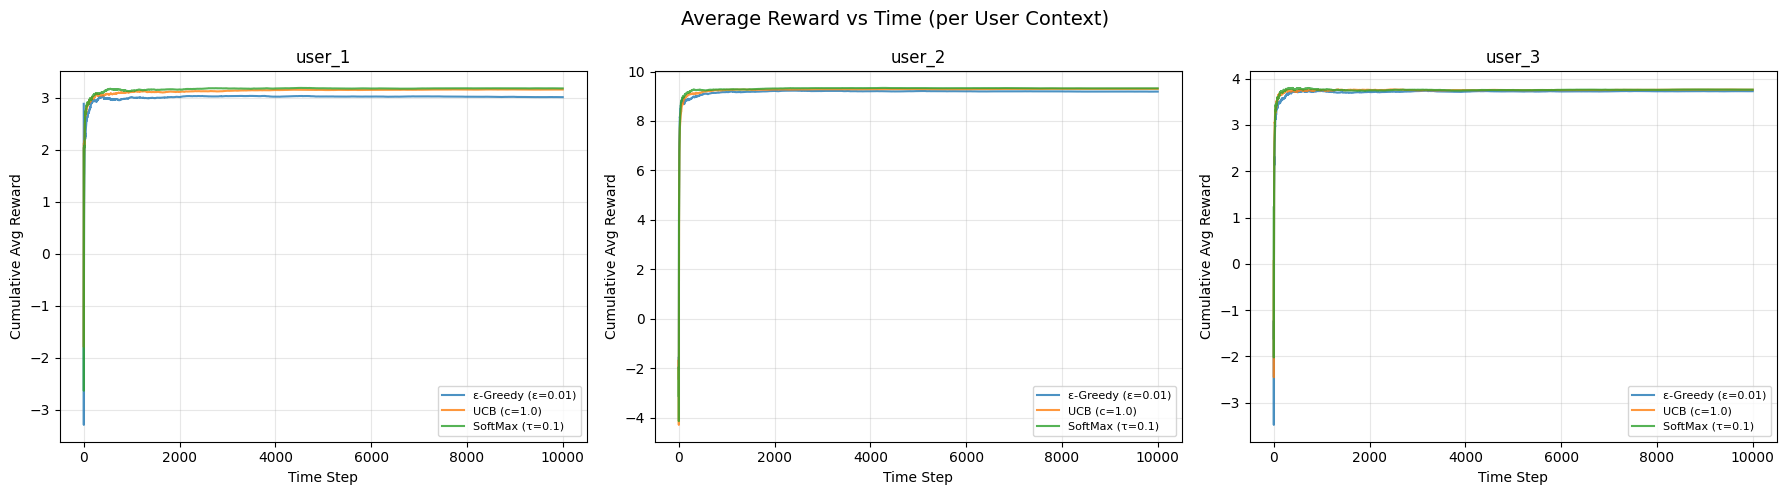

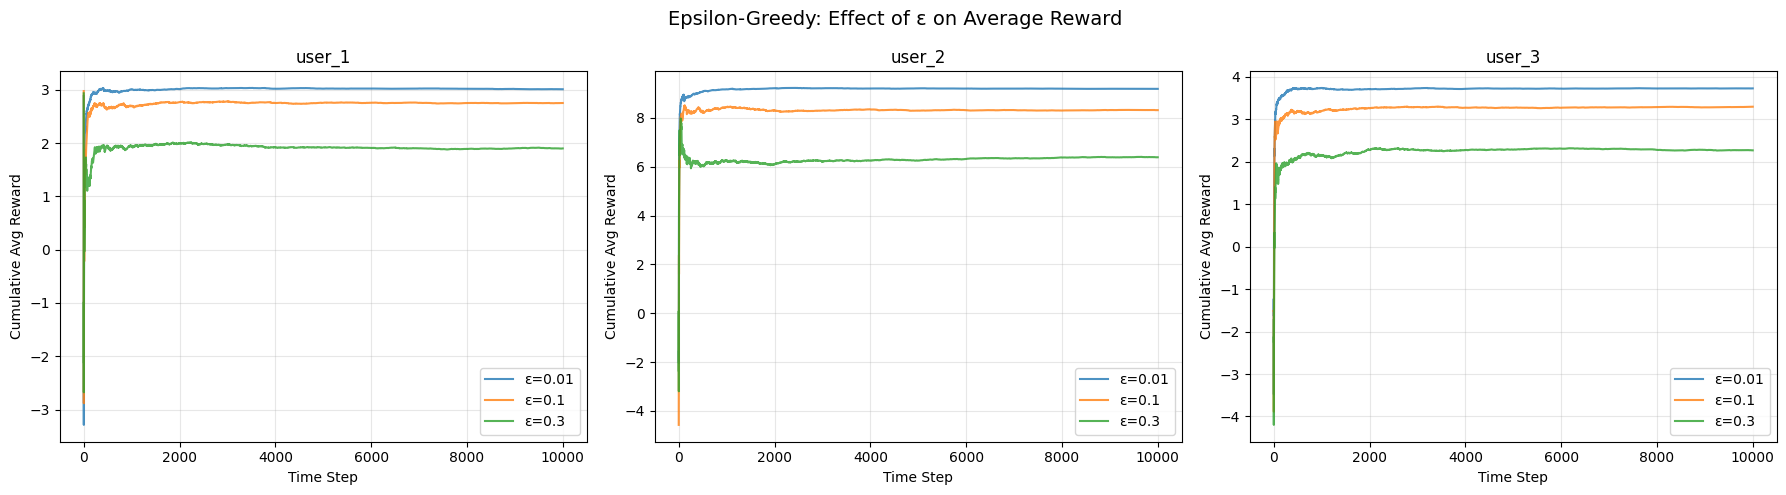

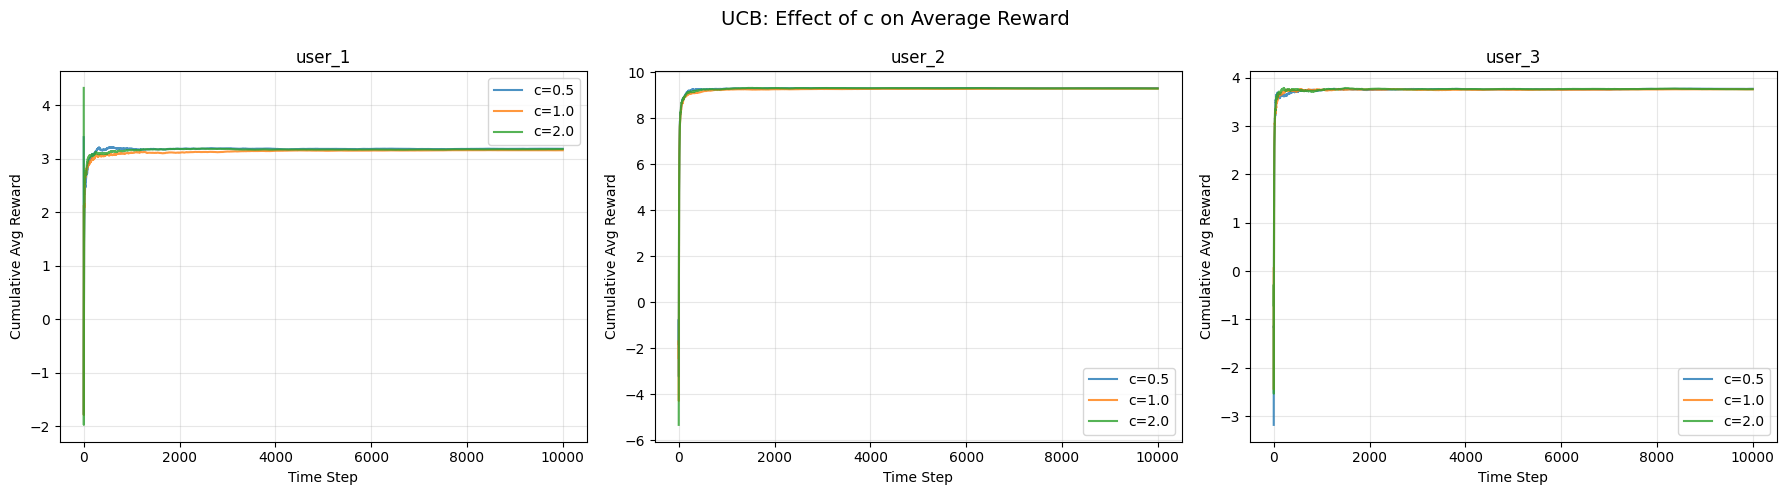

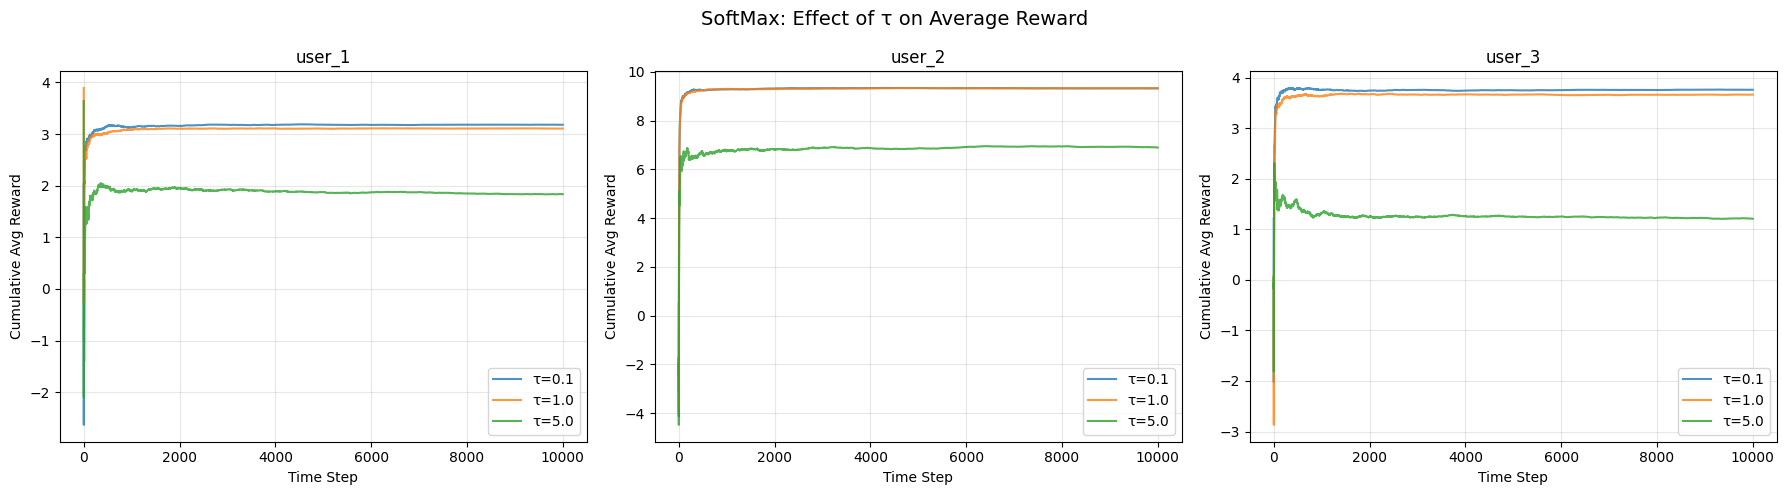

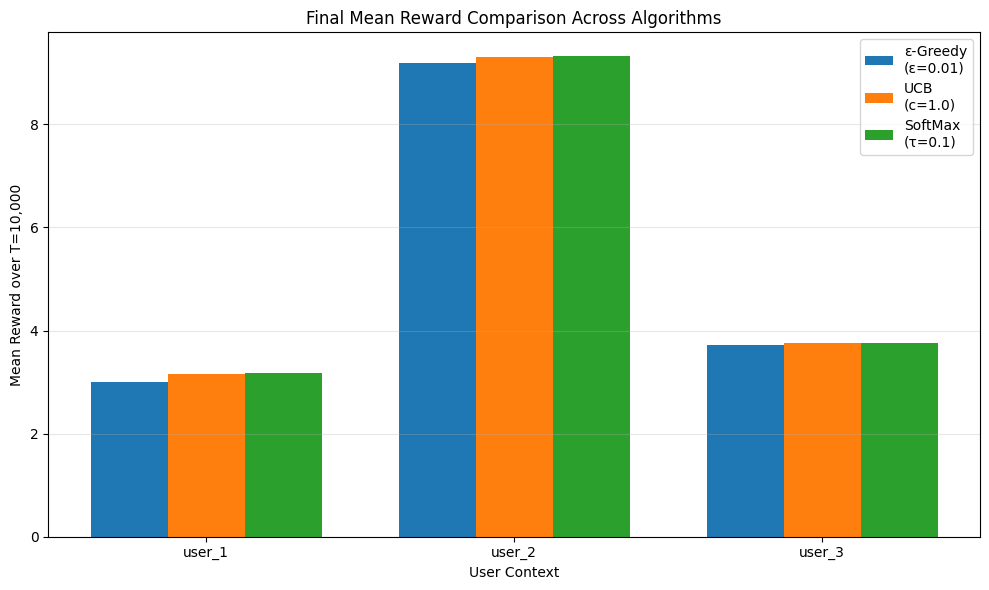

All evaluation plots generated.


In [16]:
# --- Evaluation Plots ---

def cumulative_avg(rewards):
    """Compute cumulative average reward over time."""
    return np.cumsum(rewards) / np.arange(1, len(rewards) + 1)

# ============================================================
# PLOT 1: Average Reward vs Time — All algorithms, per context
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Average Reward vs Time (per User Context)", fontsize=14)

# Use best hyperparams: eps=0.01, c=1.0, tau=0.1
for ctx_i, ctx_name in enumerate(USER_CONTEXTS):
    ax = axes[ctx_i]
    
    # Epsilon-Greedy (eps=0.01)
    r_eg = eg_results[0.01][ctx_i]['rewards']
    ax.plot(cumulative_avg(r_eg), label=f'ε-Greedy (ε=0.01)', alpha=0.8)
    
    # UCB (c=1.0)
    r_ucb = ucb_results[1.0][ctx_i]['rewards']
    ax.plot(cumulative_avg(r_ucb), label=f'UCB (c=1.0)', alpha=0.8)
    
    # SoftMax (tau=0.1)
    r_sm = sm_results[0.1][ctx_i]['rewards']
    ax.plot(cumulative_avg(r_sm), label=f'SoftMax (τ=0.1)', alpha=0.8)
    
    ax.set_title(ctx_name)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Cumulative Avg Reward')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 2: Epsilon-Greedy — Effect of ε across contexts
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Epsilon-Greedy: Effect of ε on Average Reward", fontsize=14)

for ctx_i, ctx_name in enumerate(USER_CONTEXTS):
    ax = axes[ctx_i]
    for eps in EPSILONS:
        r = eg_results[eps][ctx_i]['rewards']
        ax.plot(cumulative_avg(r), label=f'ε={eps}', alpha=0.8)
    ax.set_title(ctx_name)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Cumulative Avg Reward')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 3: UCB — Effect of c across contexts
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("UCB: Effect of c on Average Reward", fontsize=14)

for ctx_i, ctx_name in enumerate(USER_CONTEXTS):
    ax = axes[ctx_i]
    for c_val in C_VALUES:
        r = ucb_results[c_val][ctx_i]['rewards']
        ax.plot(cumulative_avg(r), label=f'c={c_val}', alpha=0.8)
    ax.set_title(ctx_name)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Cumulative Avg Reward')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 4: SoftMax — Effect of τ across contexts
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("SoftMax: Effect of τ on Average Reward", fontsize=14)

for ctx_i, ctx_name in enumerate(USER_CONTEXTS):
    ax = axes[ctx_i]
    for tau in TAU_VALUES:
        r = sm_results[tau][ctx_i]['rewards']
        ax.plot(cumulative_avg(r), label=f'τ={tau}', alpha=0.8)
    ax.set_title(ctx_name)
    ax.set_xlabel('Time Step')
    ax.set_ylabel('Cumulative Avg Reward')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# PLOT 5: Bar chart — Final mean rewards comparison
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))

algorithms = ['ε-Greedy\n(ε=0.01)', 'UCB\n(c=1.0)', 'SoftMax\n(τ=0.1)']
x = np.arange(len(USER_CONTEXTS))
width = 0.25

for alg_i, (alg_name, results, hp) in enumerate([
    ('ε-Greedy', eg_results, 0.01),
    ('UCB', ucb_results, 1.0),
    ('SoftMax', sm_results, 0.1)
]):
    means = [np.mean(results[hp][ctx_i]['rewards']) for ctx_i in range(N_CONTEXTS)]
    ax.bar(x + alg_i * width, means, width, label=algorithms[alg_i])

ax.set_xlabel('User Context')
ax.set_ylabel('Mean Reward over T=10,000')
ax.set_title('Final Mean Reward Comparison Across Algorithms')
ax.set_xticks(x + width)
ax.set_xticklabels(USER_CONTEXTS)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("All evaluation plots generated.")

## Final Observations

- Comparison of Epsilon-Greedy, UCB, and SoftMax
- Effect of hyperparameters
- Strengths and limitations of each approach


In [17]:
# --- Summary Table ---
print("=" * 85)
print(f"{'Algorithm':<25} {'Context':<10} {'Best Category':<15} {'Mean Reward':>12} {'Arm Pulls':>20}")
print("=" * 85)

# Epsilon-Greedy summary
for eps in EPSILONS:
    for ctx_i in range(N_CONTEXTS):
        res = eg_results[eps][ctx_i]
        cat = NEWS_CATEGORIES[res['best_arm']]
        mr = np.mean(res['rewards'])
        pulls = ', '.join([f"{int(c)}" for c in res['counts']])
        print(f"ε-Greedy (ε={eps:<4})      {USER_CONTEXTS[ctx_i]:<10} {cat:<15} {mr:>12.3f} {pulls:>20}")

print("-" * 85)

# UCB summary
for c_val in C_VALUES:
    for ctx_i in range(N_CONTEXTS):
        res = ucb_results[c_val][ctx_i]
        cat = NEWS_CATEGORIES[res['best_arm']]
        mr = np.mean(res['rewards'])
        pulls = ', '.join([f"{int(c)}" for c in res['counts']])
        print(f"UCB (c={c_val:<4})            {USER_CONTEXTS[ctx_i]:<10} {cat:<15} {mr:>12.3f} {pulls:>20}")

print("-" * 85)

# SoftMax summary
for tau in TAU_VALUES:
    for ctx_i in range(N_CONTEXTS):
        res = sm_results[tau][ctx_i]
        cat = NEWS_CATEGORIES[res['best_arm']]
        mr = np.mean(res['rewards'])
        pulls = ', '.join([f"{int(c)}" for c in res['counts']])
        print(f"SoftMax (τ={tau:<4})         {USER_CONTEXTS[ctx_i]:<10} {cat:<15} {mr:>12.3f} {pulls:>20}")

print("=" * 85)

# Overall best per context
print("\n--- Best Algorithm per Context (highest mean reward) ---")
for ctx_i, ctx_name in enumerate(USER_CONTEXTS):
    best_alg = ""
    best_reward = -np.inf
    for eps in EPSILONS:
        mr = np.mean(eg_results[eps][ctx_i]['rewards'])
        if mr > best_reward:
            best_reward = mr
            best_alg = f"ε-Greedy (ε={eps})"
    for c_val in C_VALUES:
        mr = np.mean(ucb_results[c_val][ctx_i]['rewards'])
        if mr > best_reward:
            best_reward = mr
            best_alg = f"UCB (c={c_val})"
    for tau in TAU_VALUES:
        mr = np.mean(sm_results[tau][ctx_i]['rewards'])
        if mr > best_reward:
            best_reward = mr
            best_alg = f"SoftMax (τ={tau})"
    print(f"  {ctx_name}: {best_alg} -> mean reward = {best_reward:.3f}")

Algorithm                 Context    Best Category    Mean Reward            Arm Pulls
ε-Greedy (ε=0.01)      user_1     ENTERTAINMENT          3.010     9887, 15, 25, 73
ε-Greedy (ε=0.01)      user_2     CRIME                  9.188     26, 26, 32, 9916
ε-Greedy (ε=0.01)      user_3     CRIME                  3.728     24, 30, 26, 9920
ε-Greedy (ε=0.1 )      user_1     CRIME                  2.752  690, 234, 262, 8814
ε-Greedy (ε=0.1 )      user_2     CRIME                  8.316  230, 280, 264, 9226
ε-Greedy (ε=0.1 )      user_3     CRIME                  3.297  243, 279, 225, 9253
ε-Greedy (ε=0.3 )      user_1     CRIME                  1.900  811, 764, 748, 7677
ε-Greedy (ε=0.3 )      user_2     CRIME                  6.387  723, 736, 779, 7762
ε-Greedy (ε=0.3 )      user_3     CRIME                  2.269  758, 737, 741, 7764
-------------------------------------------------------------------------------------
UCB (c=0.5 )            user_1     CRIME                  3.185       2

### Key Observations

1. **Best Category Across All Contexts**: CRIME consistently emerges as the highest-reward category for all three user contexts, indicating that the underlying reward distributions strongly favor this category regardless of user type.

2. **Algorithm Comparison**:
   - **UCB** and **SoftMax (low τ)** converge fastest to the optimal arm and achieve the highest cumulative rewards. They exploit aggressively once the best arm is identified.
   - **Epsilon-Greedy** with small ε (0.01) also performs well but pays a slight penalty from continued random exploration even after convergence.
   - Higher exploration parameters (ε=0.3, τ=5.0) significantly reduce mean rewards due to excessive exploration of suboptimal arms.

3. **Hyperparameter Effects**:
   - **Epsilon-Greedy**: Lower ε → higher exploitation → better mean reward. ε=0.01 achieves near-optimal whereas ε=0.3 wastes ~30% of pulls on suboptimal arms.
   - **UCB**: All c values (0.5, 1.0, 2.0) converge quickly since the confidence bounds shrink with log(t). UCB is the most robust to hyperparameter choice.
   - **SoftMax**: Very sensitive to τ. Low τ (0.1) behaves nearly greedy; high τ (5.0) approaches uniform random and degrades significantly.

4. **Context-Dependent Rewards**: user_2 receives much higher rewards (~9.3) compared to user_1 (~3.1) and user_3 (~3.8), showing the importance of contextual modeling in the bandit framework.

5. **Classification → Recommendation Pipeline**: The GradientBoosting classifier predicts user context with 91.5% validation accuracy, enabling effective context-dependent recommendations through the bandit policy.